In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [4]:
sample_data = {
    "NDVI": [0.75, 0.42, 0.15, 0.67, 0.42],
    "NDBI": [0.20, 0.55, 0.80, 0.30, 0.65],
    "LST": [28.5, 35.2, 41.8, 30.4, 38.7],
    "PopulationDensity": [1200, 4500, 8000, 2000, 6000],
    "Humidity": [65, 55, 40, 70, 50],
    "WindSpeed": [12, 8, 5, 15, 7]
}

df = pd.DataFrame(sample_data)

df

,NDVI,NDBI,LST,PopulationDensity,Humidity,WindSpeed
0,0.75,0.20,28.5,1200,65,12
1,0.42,0.55,35.2,4500,55,8
2,0.15,0.80,41.8,8000,40,5
3,0.67,0.30,30.4,2000,70,15
4,0.42,0.65,38.7,6000,50,7


In [5]:
X = df.drop("LST", axis=1)

y = df["LST"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   NDVI  NDBI  PopulationDensity  Humidity  WindSpeed
0  0.75  0.20               1200        65         12
1  0.42  0.55               4500        55          8
2  0.15  0.80               8000        40          5
3  0.67  0.30               2000        70         15
4  0.42  0.65               6000        50          7

Target:
0    28.5
1    35.2
2    41.8
3    30.4
4    38.7
Name: LST, dtype: float64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 4
Testing Samples: 1


In [7]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [8]:
predictions = model.predict(X_test)

print("Predicted Values:")
print(predictions)

print("\nActual Values:")
print(y_test.values)

Predicted Values:
[36.887]

Actual Values:
[35.2]


In [9]:
mae = mean_absolute_error(
    y_test,
    predictions
)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.6869999999999692


In [10]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
4,WindSpeed,0.241941
0,NDVI,0.215649
3,Humidity,0.211326
2,PopulationDensity,0.175236
1,NDBI,0.155847


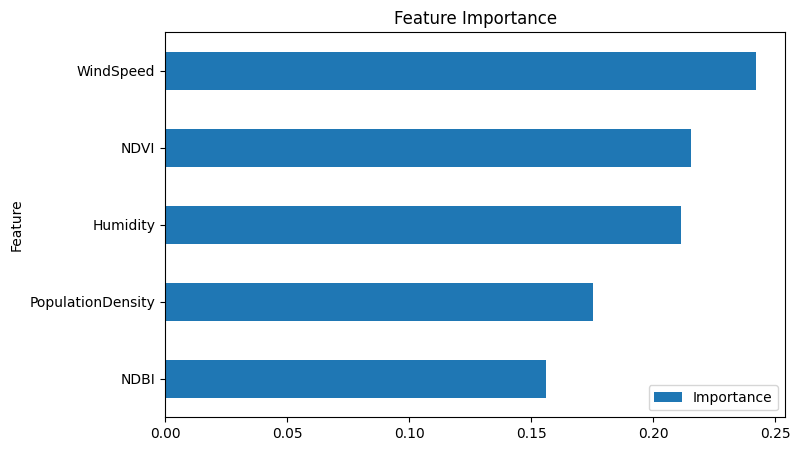

In [11]:
import matplotlib.pyplot as plt

importance.sort_values(
    by="Importance",
    ascending=True
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.show()